In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Load data
with open('main_caption_classes.json', 'r') as f:
    main_data = json.load(f)

with open('alt_caption_classes.json', 'r') as f:
    alt_data = json.load(f)

print(f"Loaded {len(main_data)} main captions and {len(alt_data)} alt captions.")

Loaded 1000 main captions and 1000 alt captions.


In [3]:
# Helper function to extract and flatten nested labels
def extract_labels(data):
    flat_labels = []
    for caption in data:
        for token_labels in caption:
            for lbl in token_labels:
                flat_labels.append(lbl)
    return flat_labels

main_labels = extract_labels(main_data)
alt_labels = extract_labels(alt_data)

main_counts = Counter(main_labels)
alt_counts = Counter(alt_labels)

print("Main Caption Label Counts:", dict(sorted(main_counts.items())))
print("Alt Caption Label Counts:", dict(sorted(alt_counts.items())))

Main Caption Label Counts: {0: 839, 1: 1521, 2: 613}
Alt Caption Label Counts: {0: 978, 1: 1428, 2: 895}


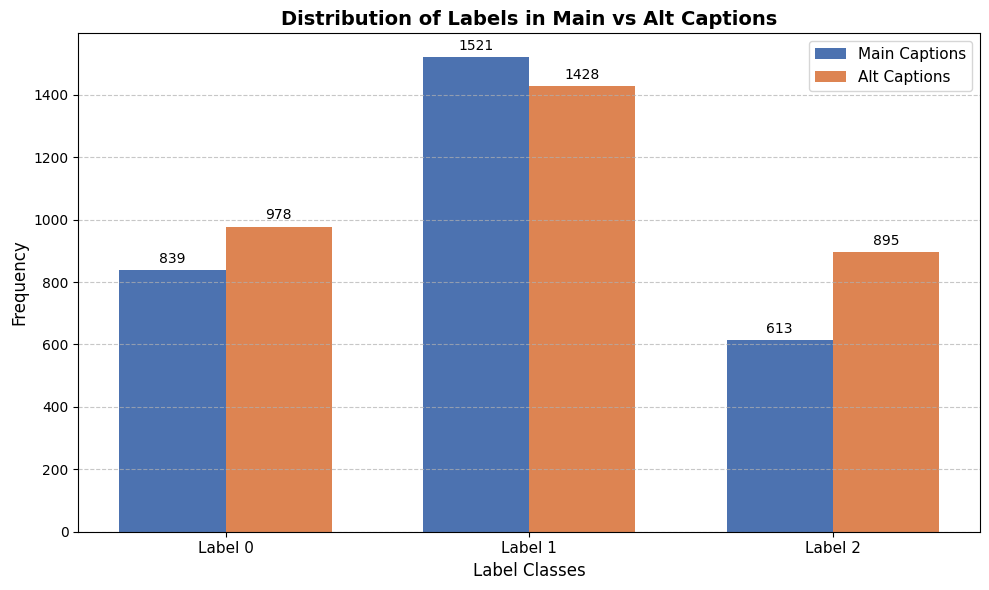

In [4]:
# Prepare data for plotting
labels = sorted(list(set(main_labels + alt_labels)))
main_freq = [main_counts.get(l, 0) for l in labels]
alt_freq = [alt_counts.get(l, 0) for l in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, main_freq, width, label='Main Captions', color='#4C72B0')
rects2 = ax.bar(x + width/2, alt_freq, width, label='Alt Captions', color='#DD8452')

ax.set_ylabel('Frequency', fontsize=12)
ax.set_xlabel('Label Classes', fontsize=12)
ax.set_title('Distribution of Labels in Main vs Alt Captions', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Label {l}' for l in labels], fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()